# RE buildout + battery storage vs. residual load

`world-of-energy`'s
[`54_germany_energy_battery_mix_costs`](https://quantitative-thinking.com/world-of-energy/notebooks/germany-energy-battery-mix-costs/)
runs a full cost-optimised dispatch (LCOE per technology, an LP-optimal
capacity mix, constant 1 MW demand). This page asks a narrower physical
question with this hub's simplest capacity-factor product
(`pecd_country_capacity_factors_simple`, the plain area/technology-mix
average used throughout this book, not MaStR-weighted): **if Germany scales
up today's wind+solar fleet by some factor and adds a battery of some size,
how much of real demand ends up covered, how much surplus gets curtailed,
and does either lever actually make Dunkelflauten go away?** No costs, no
optimisation -- just a buildout multiplier and a battery size, swept over a
grid, against real hourly demand rather than a constant or weekday-average
assumption.

**Method, in one paragraph:** today's installed solar/onshore/offshore
capacity (`capacity_by_region_year`, latest snapshot) is scaled by a single
multiplier -- so the technology *mix* is held fixed at today's ratio, only
its overall size changes. Hourly generation is capacity factor x scaled
capacity, dispatched against SMARD's actual hourly `total_load` (real
demand, not modeled). A single aggregate battery (round-trip efficiency
90%, split equally between charge/discharge via sqrt) absorbs surplus up to
its power and energy limits; anything it can't take is curtailed.
Shortfalls it can't cover are the residual load -- whatever a real system
would need to import or burn gas for. This deliberately reuses
`54`'s battery-physics approach (same split-efficiency dispatch) while
dropping everything cost-related, so the result speaks to physical
feasibility, not economics.

**What this does *not* model:** transmission constraints, other
flexibility (demand response, hydro, interconnectors), or a
multi-technology battery/gas cost trade-off -- see `54` for that fuller
picture. The point here is simpler: separate two questions that are easy
to conflate -- "how much of *average* demand can renewables + storage
cover" vs. "does that make the worst-case Dunkelflaute go away" -- and show
that the answers move very differently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insights.paths import hub_file

# Technology colors, consistent with this book's other PECD pages (04, 06, 08)
TECH_COLORS = {"solar": "#eda100", "wind_onshore": "#2a78d6", "wind_offshore": "#1baf7a"}

# Battery scenarios are an *ordinal* series (increasing storage duration), so
# they get a single-hue sequential ramp rather than distinct categorical
# hues -- "no battery" in neutral gray, then light-to-dark blue with duration.
BATTERY_COLORS = {
    "No battery": "#a9a8a2",
    "4h battery": "#9ec5f4",
    "24h battery (1 day)": "#3987e5",
    "168h battery (1 week)": "#0d366b",
}

DE_LU_CREATION_DATE = "2018-10-01"  # see 04's note: SMARD's DE-LU load/generation series is unreliable before this

## Data

DE capacity factors (`pecd_country_capacity_factors_simple`), real hourly
demand (`smard_load`), and today's installed capacity (`capacity_by_region_year`,
latest year-end snapshot), joined on their common hourly range.

In [2]:
cf = pd.read_parquet(hub_file("pecd", "pecd_country_capacity_factors_simple.parquet"))
de_cf = cf.xs("DE", axis=1, level="country")
load = pd.read_parquet(hub_file("smard", "load.parquet"))["total_load"]

panel = de_cf.join(load.rename("demand_mw"), how="inner").loc[DE_LU_CREATION_DATE:].dropna()
demand = panel["demand_mw"].values.astype(float)
avg_demand_mw = demand.mean()

TECHS = ["solar", "wind_onshore", "wind_offshore"]
cf_arrays = {tech: panel[tech].values.astype(float) for tech in TECHS}

print(f"Simulation period: {panel.index.min()} -> {panel.index.max()}  ({len(panel):,} hours)")
print(f"Average demand: {avg_demand_mw / 1000:.1f} GW")

Simulation period: 2018-10-01 00:00:00 -> 2025-12-31 22:00:00  (63,572 hours)
Average demand: 55.4 GW


In [3]:
capacity_annual = pd.read_parquet(hub_file("capacity", "capacity_by_region_year.parquet"))
is_offshore = capacity_annual["region_code"].str.startswith("DEZZ")
latest_year = capacity_annual["year"].max()
latest = capacity_annual[capacity_annual["year"] == latest_year]

CURRENT_CAPACITY_MW = {
    "solar": latest.loc[latest["technology"] == "solar", "capacity_mw"].sum(),
    "wind_onshore": latest.loc[(latest["technology"] == "wind") & ~is_offshore.reindex(latest.index, fill_value=False), "capacity_mw"].sum(),
    "wind_offshore": latest.loc[(latest["technology"] == "wind") & is_offshore.reindex(latest.index, fill_value=False), "capacity_mw"].sum(),
}
total_current_gw = sum(CURRENT_CAPACITY_MW.values()) / 1000

print(f"Current installed capacity ({latest_year} snapshot):")
for tech, mw in CURRENT_CAPACITY_MW.items():
    print(f"  {tech:15s}  {mw / 1000:6.1f} GW")
print(f"  {'total':15s}  {total_current_gw:6.1f} GW")
print(f"\nAt today's size, mean RE potential / mean demand = "
      f"{sum(cf_arrays[t].mean() * CURRENT_CAPACITY_MW[t] for t in TECHS) / avg_demand_mw:.0%}")

Current installed capacity (2026 snapshot):
  solar             111.5 GW
  wind_onshore       69.8 GW
  wind_offshore      10.9 GW
  total             192.1 GW

At today's size, mean RE potential / mean demand = 59%


## Battery dispatch simulation

One aggregate battery: surplus (generation > demand) charges it, up to its
power and remaining energy headroom; anything beyond that is curtailed.
Deficits discharge it, up to its power and remaining state of charge;
anything beyond that is residual load. Charge/discharge losses are split
equally via `sqrt(round-trip efficiency)`, matching `54`'s battery model.

In [4]:
BATTERY_ROUND_TRIP_EFFICIENCY = 0.90
EFF = np.sqrt(BATTERY_ROUND_TRIP_EFFICIENCY)

# Power capacity fixed at 30% of average demand across all battery scenarios
# (generous enough that duration -- the energy capacity -- is almost always
# the binding constraint, not power) so the sweep below isolates the effect
# of storage *duration*.
BATTERY_POWER_MW = 0.30 * avg_demand_mw

BATTERY_SCENARIOS = {
    "No battery": 0.0,
    "4h battery": 4.0,
    "24h battery (1 day)": 24.0,
    "168h battery (1 week)": 168.0,
}


def simulate(buildout_multiplier: float, duration_h: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Hourly (generation, residual_load, curtailed) arrays for one scenario."""
    gen = sum(cf_arrays[t] * CURRENT_CAPACITY_MW[t] * buildout_multiplier for t in TECHS)
    power_mw = BATTERY_POWER_MW if duration_h > 0 else 0.0
    cap_mwh = power_mw * duration_h

    n = len(gen)
    soc = 0.0
    residual = np.empty(n)
    curtailed = np.empty(n)
    for i in range(n):
        net = gen[i] - demand[i]
        if net > 0:
            can_take = min(net, power_mw, (cap_mwh - soc) / EFF) if cap_mwh > 0 else 0.0
            soc += can_take * EFF
            curtailed[i] = net - can_take
            residual[i] = 0.0
        else:
            deficit = -net
            can_give = min(deficit / EFF, power_mw / EFF, soc) if cap_mwh > 0 else 0.0
            soc -= can_give
            residual[i] = deficit - can_give * EFF
            curtailed[i] = 0.0
    return gen, residual, curtailed


def scenario_metrics(gen: np.ndarray, residual: np.ndarray, curtailed: np.ndarray) -> dict:
    avg_re_share = 1 - residual.mean() / avg_demand_mw
    curtailment_share = curtailed.sum() / gen.sum()

    # Worst sustained shortfall episode: peak-to-trough drawdown of the
    # cumulative (curtailed - residual) balance, same definition as 54's
    # "system drawdown" module. Reported as an energy magnitude (in units of
    # average demand-days) rather than a duration -- see the markdown note
    # below the drawdown chart for why duration is the less robust of the two.
    balance = np.cumsum(curtailed - residual)
    running_max = np.maximum.accumulate(balance)
    trough_idx = int(np.argmin(balance - running_max))
    peak_val = running_max[trough_idx]
    magnitude_mwh = peak_val - balance[trough_idx]

    return {
        "avg_re_share": avg_re_share,
        "curtailment_share": curtailment_share,
        "peak_residual_frac": residual.max() / avg_demand_mw,
        "worst_drawdown_demand_days": magnitude_mwh / avg_demand_mw / 24,
    }


MULTIPLIERS = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]

results = []
for multiplier in MULTIPLIERS:
    for label, duration_h in BATTERY_SCENARIOS.items():
        gen, residual, curtailed = simulate(multiplier, duration_h)
        metrics = scenario_metrics(gen, residual, curtailed)
        results.append({
            "multiplier": multiplier,
            "battery": label,
            "battery_capacity_gwh": BATTERY_POWER_MW * duration_h / 1000,
            **metrics,
        })

results = pd.DataFrame(results)
print("Battery scenarios (power fixed at "
      f"{BATTERY_POWER_MW / 1000:.1f} GW = 30% of average demand):")
for label, duration_h in BATTERY_SCENARIOS.items():
    cap_gwh = BATTERY_POWER_MW * duration_h / 1000
    print(f"  {label:24s}  {duration_h:5.0f} h   {cap_gwh:8,.0f} GWh")

Battery scenarios (power fixed at 16.6 GW = 30% of average demand):
  No battery                    0 h          0 GWh
  4h battery                    4 h         67 GWh
  24h battery (1 day)          24 h        399 GWh
  168h battery (1 week)       168 h      2,795 GWh


## Average renewable share and curtailment vs. buildout

Left: share of demand covered on average by RE + battery (`1 - average
residual load / average demand`). Right: share of *produced* RE energy
that ends up curtailed. Same x-axis, same battery-scenario colors.

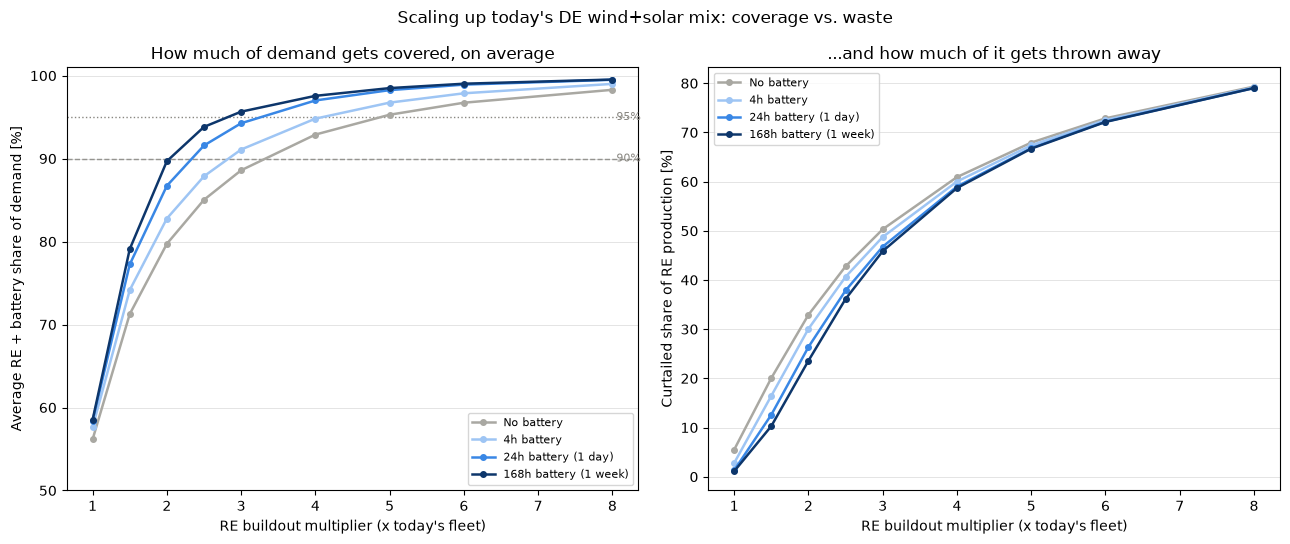

In [5]:
fig, (ax_share, ax_curt) = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)

for label in BATTERY_SCENARIOS:
    sub = results[results["battery"] == label].sort_values("multiplier")
    ax_share.plot(sub["multiplier"], sub["avg_re_share"] * 100, marker="o", markersize=4,
                  linewidth=1.8, color=BATTERY_COLORS[label], label=label)
    ax_curt.plot(sub["multiplier"], sub["curtailment_share"] * 100, marker="o", markersize=4,
                 linewidth=1.8, color=BATTERY_COLORS[label], label=label)

for target, style in [(90, "--"), (95, ":")]:
    ax_share.axhline(target, color="#898781", linewidth=1, linestyle=style, zorder=0)
    ax_share.text(MULTIPLIERS[-1], target, f" {target}%", color="#898781", fontsize=8, va="center")

ax_share.set_ylabel("Average RE + battery share of demand [%]")
ax_share.set_xlabel("RE buildout multiplier (x today's fleet)")
ax_share.set_title("How much of demand gets covered, on average")
ax_share.set_ylim(50, 101)
ax_share.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_share.set_axisbelow(True)
ax_share.legend(fontsize=8, loc="lower right")

ax_curt.set_ylabel("Curtailed share of RE production [%]")
ax_curt.set_xlabel("RE buildout multiplier (x today's fleet)")
ax_curt.set_title("...and how much of it gets thrown away")
ax_curt.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_curt.set_axisbelow(True)
ax_curt.legend(fontsize=8, loc="upper left")

fig.suptitle("Scaling up today's DE wind+solar mix: coverage vs. waste")
fig.tight_layout()
plt.show()

Two things happen at once as the buildout multiplier grows: the average RE
share climbs toward 100%, but so does curtailment -- because the same extra
capacity that fills winter gaps also massively overshoots on a windy summer
afternoon. A battery shifts that curve outward (less curtailment, or less
buildout, for the same average share) but doesn't change its shape. Getting
from ~90% to ~95% average share costs roughly as much extra buildout (and
curtailment) as getting from 0% to ~80% did -- steeply diminishing returns
past the "comparatively cheap" 90-95% band the introduction points at.

## Peak residual load: the backup capacity question

Average share covered is one question; **how big must standby backup
capacity be** is another. This plots the single worst hour's residual load
(as a fraction of *average* demand) per scenario -- i.e. what a gas fleet
(or import capacity) sized for "the worst hour in ~7 years" would need to
cover, regardless of how rarely that hour occurs.

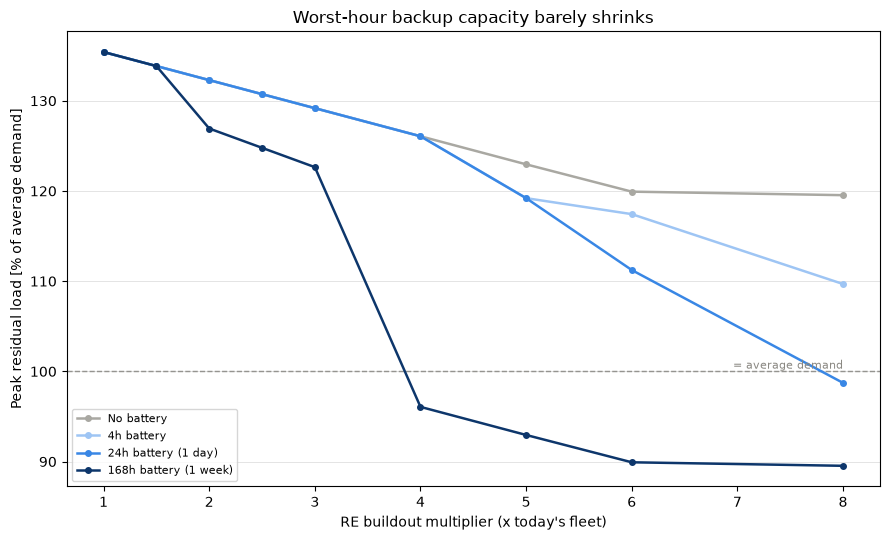

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for label in BATTERY_SCENARIOS:
    sub = results[results["battery"] == label].sort_values("multiplier")
    ax.plot(sub["multiplier"], sub["peak_residual_frac"] * 100, marker="o", markersize=4,
            linewidth=1.8, color=BATTERY_COLORS[label], label=label)

ax.axhline(100, color="#898781", linewidth=1, linestyle="--", zorder=0)
ax.text(MULTIPLIERS[-1], 100, " = average demand", color="#898781", fontsize=8, va="bottom", ha="right")
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Peak residual load [% of average demand]")
ax.set_title("Worst-hour backup capacity barely shrinks")
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

The 4h and 24h batteries barely move this line at all -- too small to still
hold meaningful charge by the time a rare, extreme hour arrives. The 1-week
battery is the exception: once buildout is large enough to keep it
routinely topped up (~4x and up), it cuts the worst hour substantially,
from ~125% down to ~90-96% of average demand. But even that best case
doesn't get close to zero -- at 8x today's fleet, the single worst hour in
~7 years *still* needs backup capacity equal to ~90% of average demand, a
conventional/import fleet that would sit idle nearly all year to cover it.

## Does the worst multi-day shortfall ever go away?

Cumulative-balance drawdown (`54`'s "system drawdown" method): running sum
of curtailed-minus-residual energy, then the deepest peak-to-trough decline
-- the total energy a backup source would have had to supply across the
single worst sustained episode in ~7 years, in units of average-demand-days.

**Caveat visible in the chart itself:** at 1.0x-1.5x buildout the system is
in *chronic* deficit (RE rarely exceeds demand at all), so the "episode"
is effectively the whole multi-year record, not a discrete weather event --
those two points measure something different from the rest of the curve
and are shown for continuity, not as a comparable Dunkelflaute figure.

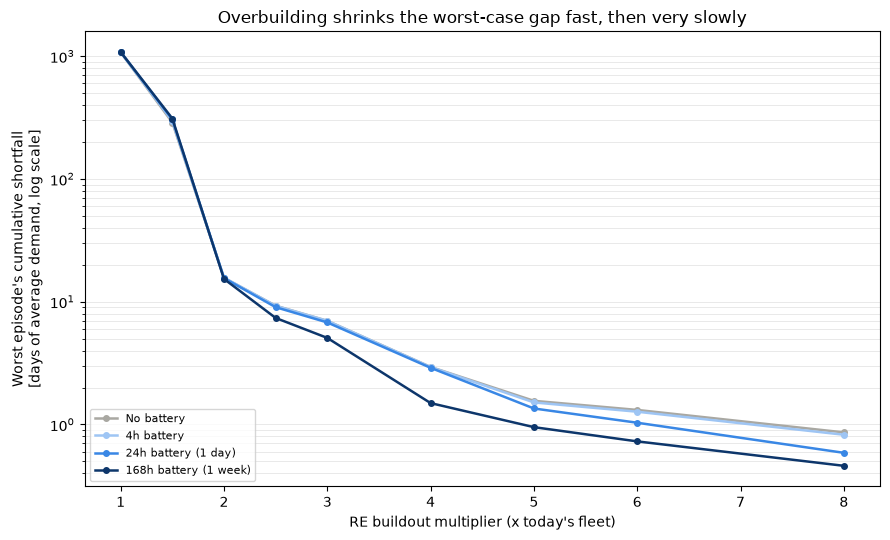

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for label in BATTERY_SCENARIOS:
    sub = results[results["battery"] == label].sort_values("multiplier")
    ax.plot(sub["multiplier"], sub["worst_drawdown_demand_days"], marker="o", markersize=4,
            linewidth=1.8, color=BATTERY_COLORS[label], label=label)

ax.set_yscale("log")
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Worst episode's cumulative shortfall\n[days of average demand, log scale]")
ax.set_title("Overbuilding shrinks the worst-case gap fast, then very slowly")
ax.yaxis.grid(True, which="both", linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

In [8]:
demand_day_twh = avg_demand_mw * 24 / 1e6
for multiplier in [2.0, 3.0, 8.0]:
    no_battery = results[(results["multiplier"] == multiplier) & (results["battery"] == "No battery")].iloc[0]
    with_168h = results[(results["multiplier"] == multiplier) & (results["battery"] == "168h battery (1 week)")].iloc[0]
    print(f"{multiplier:.0f}x buildout: worst episode = {no_battery['worst_drawdown_demand_days'] * demand_day_twh:.1f} TWh "
          f"(no battery) / {with_168h['worst_drawdown_demand_days'] * demand_day_twh:.1f} TWh (168h battery) "
          f"-- vs. the battery's own {BATTERY_POWER_MW * 168 / 1e6:.1f} TWh capacity")

2x buildout: worst episode = 20.8 TWh (no battery) / 20.4 TWh (168h battery) -- vs. the battery's own 2.8 TWh capacity
3x buildout: worst episode = 9.3 TWh (no battery) / 6.7 TWh (168h battery) -- vs. the battery's own 2.8 TWh capacity
8x buildout: worst episode = 1.1 TWh (no battery) / 0.6 TWh (168h battery) -- vs. the battery's own 2.8 TWh capacity


Once buildout is large enough that the chronic deficit disappears (roughly
2x today's fleet), the worst-episode metric drops fast, then flattens: going
from 4x to 8x buildout -- doubling an already enormous fleet again -- only
takes the worst episode from a few days' worth of average demand to about a
day's worth. Batteries help here, but less than buildout does, and for a
reason worth separating: at 2x buildout the worst episode (~21 TWh) dwarfs
even the enormous 168h/~2.8 TWh battery, so it barely dents it (~2%) --
genuinely a capacity-insufficiency story. By 8x buildout the episode itself
has shrunk to well *below* the battery's own capacity, yet the battery still
only cuts it by roughly half, not to zero -- at that point it's no longer
about total capacity but about *timing*: the battery isn't necessarily full
when the drought begins, and its fixed power rating limits how fast it can
charge beforehand or discharge during it. Either way, across the whole
range tested, buildout moves this line by orders of magnitude while battery
duration -- even pushed to an unrealistic week's worth -- moves it by at
most a factor of ~2.

## What the residual-load curve looks like at three scenarios

Same three ingredients (buildout, battery), but instead of one summary
number per scenario: every hour's residual load, sorted descending, as a
share of average demand. This is the shape a duration-curve/backup-fleet
planner actually cares about -- not just the headline average.

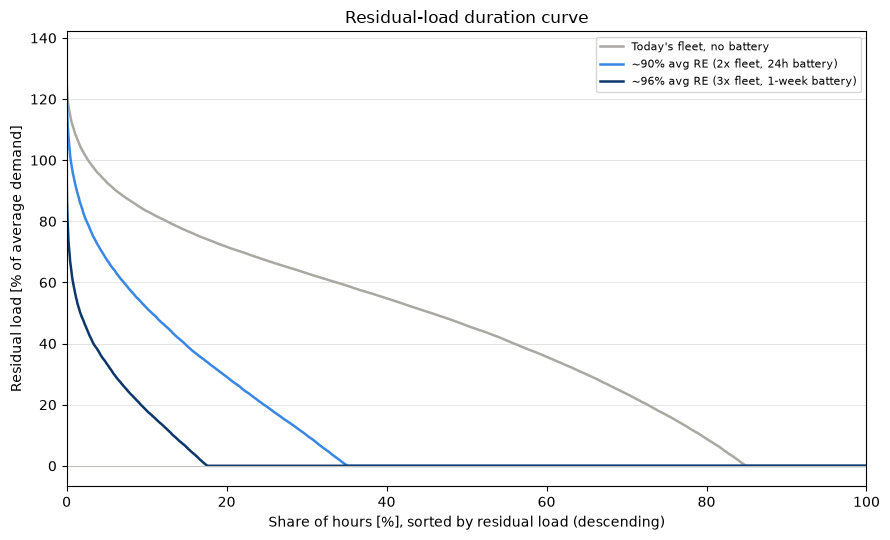

In [9]:
SCENARIOS_TO_TRACE = [
    ("Today's fleet, no battery", 1.0, "No battery"),
    ("~90% avg RE (2x fleet, 24h battery)", 2.0, "24h battery (1 day)"),
    ("~96% avg RE (3x fleet, 1-week battery)", 3.0, "168h battery (1 week)"),
]
TRACE_COLORS = ["#a9a8a2", "#3987e5", "#0d366b"]

fig, ax = plt.subplots(figsize=(9, 5.5))
for (label, multiplier, battery_label), color in zip(SCENARIOS_TO_TRACE, TRACE_COLORS):
    duration_h = BATTERY_SCENARIOS[battery_label]
    _, residual, _ = simulate(multiplier, duration_h)
    sorted_residual = np.sort(residual)[::-1] / avg_demand_mw * 100
    hours_pct = np.arange(1, len(sorted_residual) + 1) / len(sorted_residual) * 100
    ax.plot(hours_pct, sorted_residual, linewidth=1.8, color=color, label=label)

ax.set_xlabel("Share of hours [%], sorted by residual load (descending)")
ax.set_ylabel("Residual load [% of average demand]")
ax.set_title("Residual-load duration curve")
ax.set_xlim(0, 100)
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

The high-RE curve (dark blue) hugs zero for most of the distribution --
the median hour has *no* residual load at all, vs. ~46% of average demand
for today's baseline. That's what a 96%-average-share number promises. But
the gap closes fast heading left: in the worst 0.1% of hours (~63 of them,
across ~7 years), the high-RE scenario is still at ~81% of average demand
vs. the baseline's ~121% -- a real improvement, but nowhere near the ~100%
reduction seen at the median. Buildout and storage compress the *bulk* of
the distribution far more effectively than they compress the *tail* --
which is exactly the Dunkelflaute sliver, and the reason backup capacity
can't be sized off the average.

## Summary: four scenarios side by side

In [10]:
NAMED_SCENARIOS = [
    ("Today's fleet", 1.0, "No battery"),
    ("~90% avg RE, with 24h battery", 2.0, "24h battery (1 day)"),
    ("~95% avg RE, with 1-week battery", 3.0, "168h battery (1 week)"),
    ("~95% avg RE, no battery at all", 5.0, "No battery"),
]

summary_rows = []
for label, multiplier, battery_label in NAMED_SCENARIOS:
    row = results[(results["multiplier"] == multiplier) & (results["battery"] == battery_label)].iloc[0]
    summary_rows.append({
        "scenario": label,
        "buildout": f"{multiplier:.1f}x ({multiplier * total_current_gw:,.0f} GW)",
        "battery": battery_label,
        "battery_gwh": f"{row['battery_capacity_gwh']:,.0f}",
        "avg_re_share": f"{row['avg_re_share']:.0%}",
        "curtailed": f"{row['curtailment_share']:.0%}",
        "peak_residual": f"{row['peak_residual_frac']:.0%} of avg demand",
        "worst_episode": f"{row['worst_drawdown_demand_days']:.1f} demand-days",
    })

summary = pd.DataFrame(summary_rows).set_index("scenario")
print(summary.to_string())

                                       buildout                battery battery_gwh avg_re_share curtailed       peak_residual       worst_episode
scenario                                                                                                                                         
Today's fleet                     1.0x (192 GW)             No battery           0          56%        6%  135% of avg demand  1074.6 demand-days
~90% avg RE, with 24h battery     2.0x (384 GW)    24h battery (1 day)         399          87%       26%  132% of avg demand    15.6 demand-days
~95% avg RE, with 1-week battery  3.0x (576 GW)  168h battery (1 week)       2,795          96%       46%  123% of avg demand     5.1 demand-days
~95% avg RE, no battery at all    5.0x (961 GW)             No battery           0          95%       68%  123% of avg demand     1.6 demand-days


## Takeaways

- **The first ~90-95% of average renewable share is comparatively cheap.**
  Roughly doubling today's wind+solar fleet, paired with a modest (24h)
  battery, gets ~90% of demand covered on average with "only" ~25-30%
  curtailment of RE production.
- **Chasing the last few percent is much more expensive, with or without a
  battery.** Reaching ~95% average share needs either a much bigger battery
  on top of 3x buildout, or ~5x buildout with no battery at all and ~65-70%
  of RE production thrown away -- the curtailment cost of skipping storage
  entirely is severe, confirming the "you'd have to massively overbuild
  *and* waste most of it" intuition.
- **Neither lever comes close to closing the Dunkelflaute tail, even at
  absurd scale.** A realistic-sized battery (4h-24h) barely moves the
  worst-hour or worst-episode numbers at all. Even the enormous 168h/~2.8
  TWh scenario -- far beyond anything plausibly deployable -- only ever
  trims them by a third to a half; it never gets close to zero, because
  backup need is set by a specific windless, sunless multi-day stretch that
  buildout doesn't fill and that no battery this size is reliably full for
  when it hits. A 90-95% average share is a *buildout/storage* problem with
  a comparatively good cost-benefit ratio; the remaining sliver is a
  *backup capacity* problem that scaling the same two levers further
  doesn't solve.